# Cargando data y limpeza

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cargar datos
df = pd.read_csv('../data/precios_p2p.csv', parse_dates=['fecha'])
df.head()

,fecha,tipo,precio,monto,asset,fiat,metodos_pago
0,2026-08-18T20:47:48.114803,SELL,912.499,1896.68,USDT,VES,Banesco
1,2026-08-18T20:47:47.799681,BUY,915.000,3000.00,USDT,VES,Banco de Venezuela
2,2026-08-18T20:17:09.014314,SELL,910.000,325.18,USDT,VES,"Mercantil, Banco de Venezuela"
3,2026-08-18T20:17:08.684576,BUY,914.500,220000.00,USDT,VES,"Banco de Venezuela, Bank Transfer"
4,2026-08-18T19:47:09.116678,SELL,910.999,1896.68,USDT,VES,Bancamiga


In [4]:
# cleaning data
df.dropna()
df = df.dropna().copy()
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce', utc=True)
df = df.dropna(subset=['fecha']).reset_index(drop=True)
df['fecha'] = df['fecha'].dt.tz_localize(None)
# asegurarse datetime y normalizar segundos
df['fecha'] = pd.to_datetime(df['fecha']).dt.floor('min')
m = df['fecha'].dt.minute
df.loc[m.between(1, 14), 'fecha'] = df.loc[m.between(1, 14), 'fecha'].dt.floor('h')
df.loc[m.between(15, 29), 'fecha'] = df.loc[m.between(15, 29), 'fecha'].dt.floor('h')
df.loc[m.between(31, 44), 'fecha'] = df.loc[m.between(31, 44), 'fecha'].dt.floor('h')
df.loc[m.between(45, 59), 'fecha'] = df.loc[m.between(45, 59), 'fecha'].dt.floor('h')

df['Dia'] = df['fecha'].dt.day_name()
df.head()

,fecha,tipo,precio,monto,asset,fiat,metodos_pago,Dia
0,2026-08-18 20:00:00,SELL,912.499,1896.68,USDT,VES,Banesco,Tuesday
1,2026-08-18 20:00:00,BUY,915.000,3000.00,USDT,VES,Banco de Venezuela,Tuesday
2,2026-08-18 20:00:00,SELL,910.000,325.18,USDT,VES,"Mercantil, Banco de Venezuela",Tuesday
3,2026-08-18 20:00:00,BUY,914.500,220000.00,USDT,VES,"Banco de Venezuela, Bank Transfer",Tuesday
4,2026-08-18 19:00:00,SELL,910.999,1896.68,USDT,VES,Bancamiga,Tuesday


# Tabla pivote

In [5]:
# --- Spread por timestamp (pivotear compra/venta) ---

pivot = df.pivot_table(
    index='fecha', columns='tipo', values='precio', aggfunc='mean'
)
pivot['spread'] = pivot['BUY'] - pivot['SELL']
pivot['spread_pct'] = (pivot['spread'] / pivot['BUY']) * 100
pivot.head()


tipo,BUY,SELL,spread,spread_pct
fecha,,,,
2026-08-10 14:00:00,870.0,875.0,-5.0,-0.574713
2026-08-10 14:30:00,870.0,874.0,-4.0,-0.459770
2026-08-10 15:00:00,867.5,868.9,-1.4,-0.161383
2026-08-10 15:30:00,870.0,866.7,3.3,0.379310
2026-08-10 16:00:00,870.0,866.0,4.0,0.459770


# Grafica Margen por dia

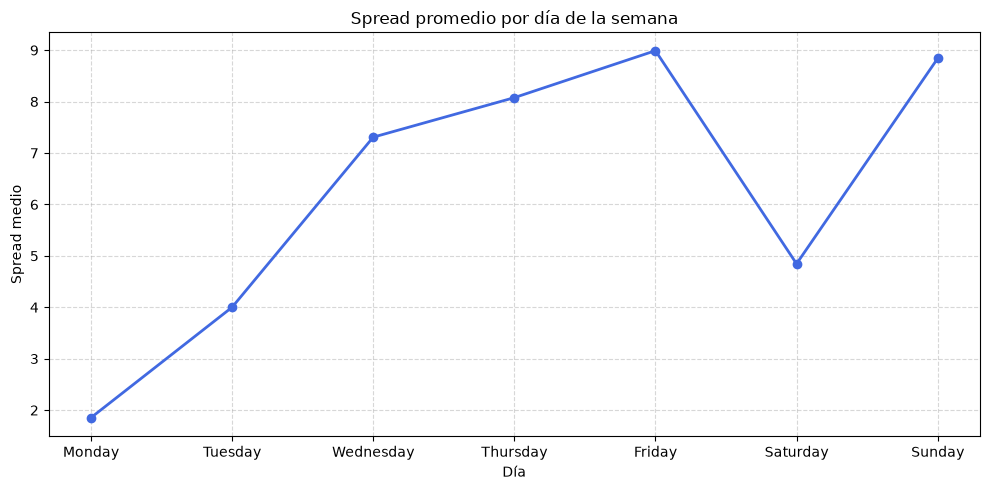

In [6]:
# --- Spread promedio por día de la semana ---

pivot_dia = pivot.copy()
pivot_dia['dia_semana'] = pivot_dia.index.day_name()
resumen_dia = pivot_dia.groupby('dia_semana')['spread'].agg(['mean'])
# Ordenar días correctamente
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
resumen_dia = resumen_dia.reindex(orden_dias)
plt.figure(figsize=(10, 5))
resumen_dia['mean'].plot(kind='line', marker='o', linewidth=2, color='royalblue')
plt.title('Spread promedio por día de la semana')
plt.xlabel('Día')
plt.ylabel('Spread medio')
plt.xticks(range(len(resumen_dia.index)), resumen_dia.index)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Grafica de calor semana entera

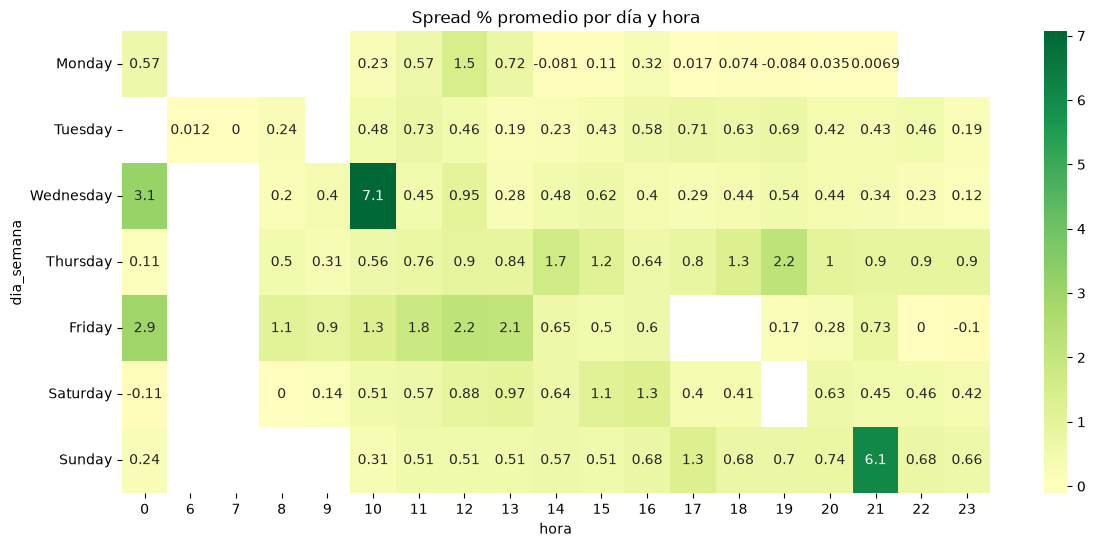

In [9]:
# --- Heatmap día vs hora (MUY útil para encontrar patrones) ---
pivot_dia['hora'] = pivot_dia.index.hour
heatmap_data = pivot_dia.pivot_table(
    index='dia_semana', columns='hora', values='spread_pct', aggfunc='mean'
).reindex(orden_dias)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap='RdYlGn', annot=True, center=0)
plt.title('Spread % promedio por día y hora')
plt.show()

# Grafica de horas pico 

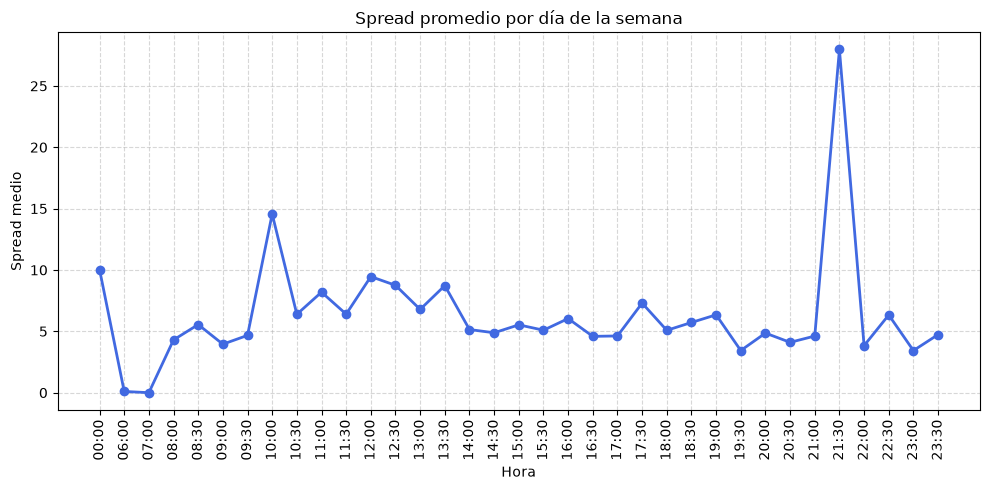

In [83]:
pivot_hora = pivot.copy()
pivot_hora['hora'] = pivot_hora.index.strftime('%H:%M')
resumen_hora = pivot_hora.groupby('hora')['spread'].agg(['mean'])

plt.figure(figsize=(10, 5))
resumen_hora['mean'].plot(kind='line', marker='o', linewidth=2, color='royalblue')
plt.title('Spread promedio por día de la semana')
plt.xlabel('Hora')
plt.xticks(rotation=90)
plt.ylabel('Spread medio')
plt.xticks(range(len(resumen_hora.index)), resumen_hora.index)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Metodos mas usados

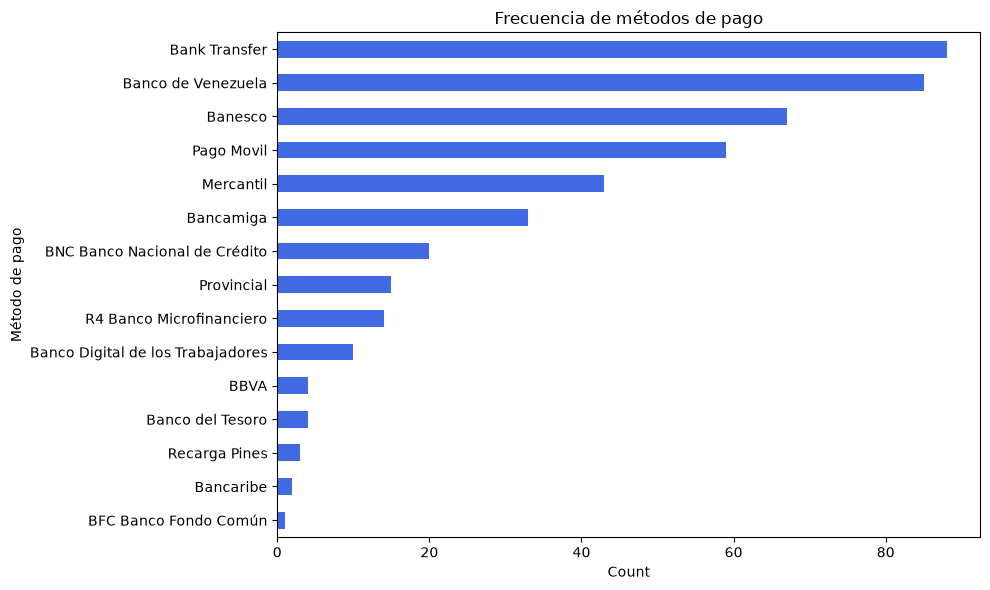

In [105]:
metodos_raw = df.drop(columns=['fecha', 'tipo'])
metodos_raw.drop_duplicates(inplace=True)

metodos = metodos_raw['metodos_pago'].str.split(',').explode().str.strip()
metodos_conteo = metodos.value_counts().to_frame('count')
plt.figure(figsize=(10,6))
metodos_conteo_sorted = metodos_conteo.sort_values('count', ascending=True)
metodos_conteo_sorted['count'].plot(kind='barh', color='royalblue')
plt.xlabel('Count')
plt.ylabel('Método de pago')
plt.title('Frecuencia de métodos de pago')
plt.tight_layout()
plt.show()